In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load the Dataset
# The dataset doesn't have a header, so we'll provide column names manually.
# Missing values are denoted by '?', so we'll specify that.
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv('../data/heart_disease.csv', header=None, names=column_names, na_values='?')

In [3]:
# 3. Initial Data Exploration
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Information:")
df.info()
print("\nMissing values in each column:")
print(df.isnull().sum())


First 5 rows of the dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   t

In [4]:
# 4. Handle Missing Values
# 'ca' (number of major vessels) and 'thal' have missing values.
# We will use median for 'ca' and mode for 'thal' as they are categorical/discrete.
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# 5. Data Transformation
# The 'target' column has values 0, 1, 2, 3, 4.
# For simplicity, we'll convert this into a binary classification problem:
# 0 = No heart disease, 1 = Presence of heart disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("\nTarget variable distribution:")
print(df['target'].value_counts())



Target variable distribution:
target
0    164
1    139
Name: count, dtype: int64


In [6]:
# 6. Data Encoding (One-Hot Encoding)
# Identify categorical columns. Based on the dataset description, 'cp', 'restecg', 'slope', and 'thal' are categorical.
# 'sex', 'fbs', 'exang' are already binary (0/1).
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataset columns after one-hot encoding:")
print(df.columns)


Dataset columns after one-hot encoding:
Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'ca', 'target', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0',
       'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')


In [7]:
# 7. Feature Scaling
# We will use StandardScaler for numerical features.
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Save the scaler to use it later in the Streamlit app
import joblib
joblib.dump(scaler, '../models/scaler.pkl')

print("\nFirst 5 rows of the final preprocessed data:")
print(df.head())


First 5 rows of the final preprocessed data:
        age  sex  trestbps      chol  fbs   thalach  exang   oldpeak   ca  \
0  0.948726  1.0  0.757525 -0.264900  1.0  0.017197    0.0  1.087338  0.0   
1  1.392002  1.0  1.611220  0.760415  0.0 -1.821905    1.0  0.397182  3.0   
2  1.392002  1.0 -0.665300 -0.342283  0.0 -0.902354    1.0  1.346147  2.0   
3 -1.932564  1.0 -0.096170  0.063974  0.0  1.637359    0.0  2.122573  0.0   
4 -1.489288  0.0 -0.096170 -0.825922  0.0  0.980537    0.0  0.310912  0.0   

   target  cp_2.0  cp_3.0  cp_4.0  restecg_1.0  restecg_2.0  slope_2.0  \
0       0   False   False   False        False         True      False   
1       1   False   False    True        False         True       True   
2       1   False   False    True        False         True       True   
3       0   False    True   False        False        False      False   
4       0    True   False   False        False         True      False   

   slope_3.0  thal_6.0  thal_7.0  
0       Tru

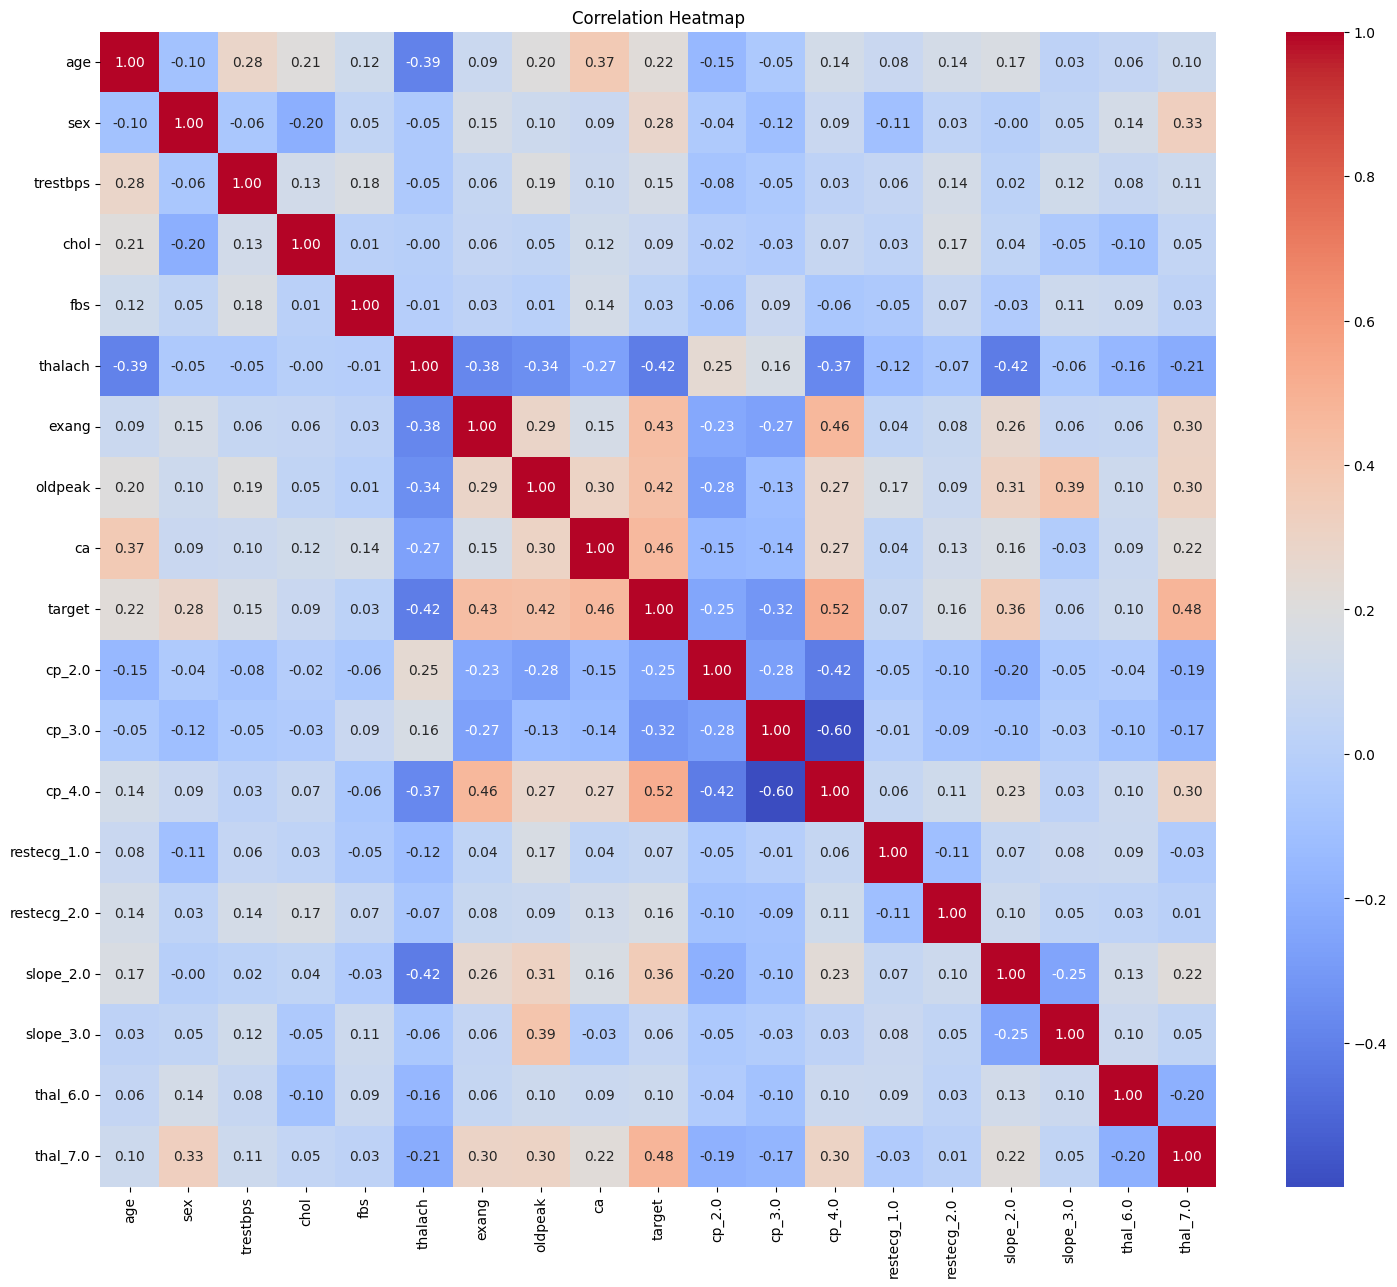

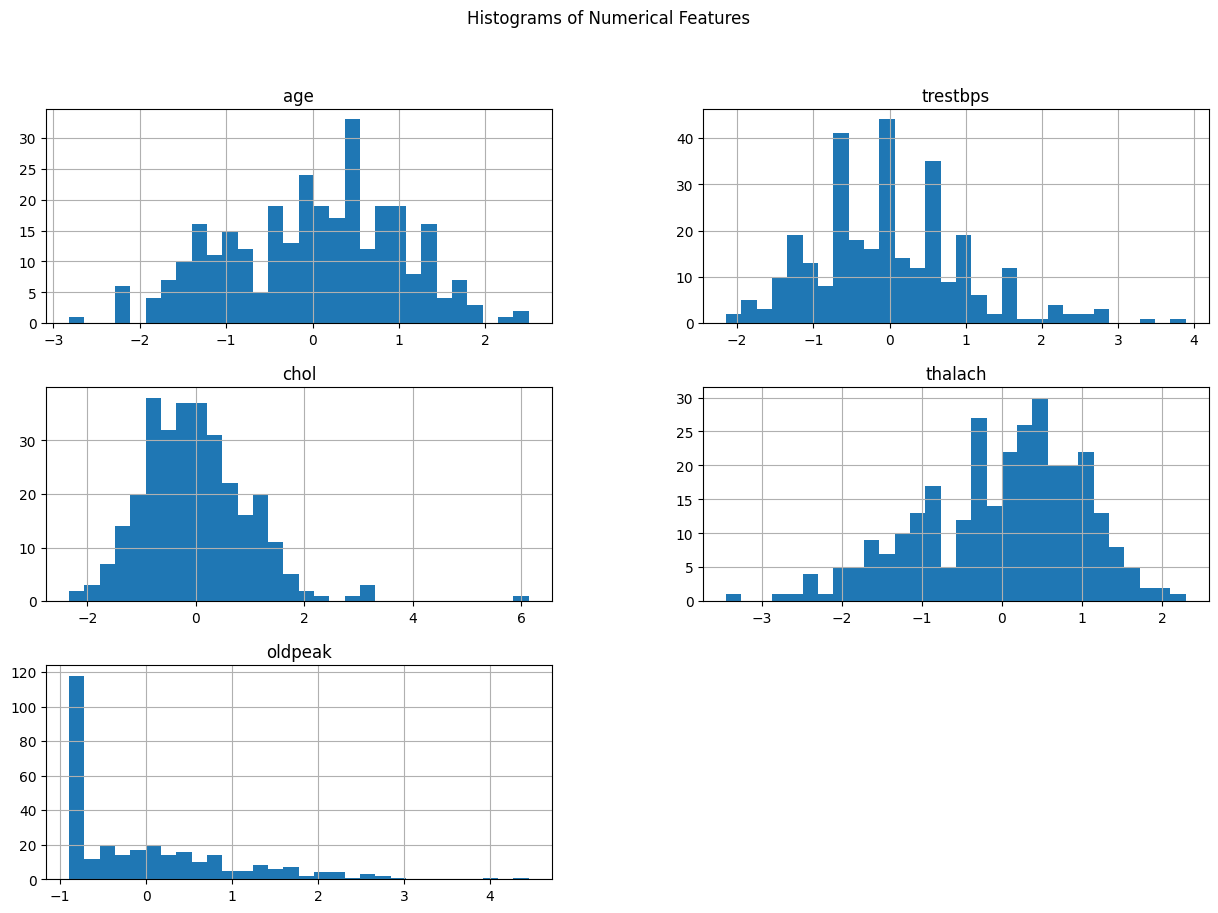

In [8]:
# 8. Exploratory Data Analysis (EDA)
# Correlation Heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Histograms for numerical features
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()

In [9]:
# 9. Save the Cleaned Dataset
df.to_csv('../data/cleaned_heart_disease.csv', index=False)
print("\nCleaned data saved to 'data/cleaned_heart_disease.csv'")


Cleaned data saved to 'data/cleaned_heart_disease.csv'
